In [243]:
#####################################bayes_opt库实现贝叶斯优化，基于高斯，且只能用高斯过程，自定义采集函数（poi、ei、ucb）##########
############去除重复行有单独的代码，命名为：删除重复行（第六篇）#################################
import pandas as pd
import csv
import os
from sklearn.preprocessing import StandardScaler
#from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from bayes_opt import BayesianOptimization
import numpy as np
from bayes_opt import util
Q=1
output_dir_path = r'D:\桌面文件\第六篇文章\output'
if not os.path.exists(output_dir_path):
   os.makedirs(output_dir_path)

def objective(n_estimators, max_depth, min_samples_split, min_samples_leaf):
# 加载数据集
    dataset = pd.read_excel(r"E:\论文5\a\特征优化 CV\0908\UAV0908.xlsx")
    dataset.head()
    # 准备数据
    X, y = dataset.iloc[:,:-1], dataset.iloc[:,-1] #可以表示x为除了最后一列，y为最后一列

# 归一化特征数据
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

# 定义XGBoost回归器
   # xgb = XGBRegressor(
   # n_estimators=int(n_estimators),
    #max_depth=int(max_depth),
   # learning_rate=learning_rate,
  #  colsample_bytree=colsample_bytree,
  #  random_state=1)
   
# 定义随机森林回归器
    model = RandomForestRegressor(n_estimators=int(n_estimators),
                              max_depth=int(max_depth),
                              min_samples_split=int(min_samples_split),
                              min_samples_leaf=int(min_samples_leaf),
                              max_features=20, 
                              random_state=Q)

# 计算交叉验证得分的负值
    cv_score = -cross_val_score(model, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error').mean()

# 保存当前trial的结果
    output_file_path = os.path.join(output_dir_path, f'trial_{len(os.listdir(output_dir_path))+1}.csv')
    with open(output_file_path, 'w', newline='', encoding='utf-8') as f:
        
        writer = csv.writer(f)
        writer.writerow(['params', 'value'])
        writer.writerow([{'n_estimators': int(n_estimators), 'max_depth': int(max_depth), 
                      'min_samples_split': int(min_samples_split), 'min_samples_leaf': int(min_samples_leaf)}, cv_score])
        return cv_score

pbounds = {'n_estimators': (50, 100), 'max_depth': (3, 10), 'min_samples_split': (2, 10), 'min_samples_leaf': (1, 10)}
optimizer = BayesianOptimization(
    f=objective,
    pbounds=pbounds,
    verbose=2,
    random_state=Q,)

optimizer.set_gp_params(normalize_y=True)#设置高斯过程
acq_func = util.UtilityFunction(kind='poi', kappa=2.576, xi=0.0)#设置采集函数（ei、poi、ucb）
optimizer.maximize(n_iter=1, acquisition_function=acq_func)#设置迭代次数



rows = []
for i, result in enumerate(optimizer.res):  
    output_file_path = os.path.join(output_dir_path, f'trial_{i+1}.csv') 
    with open(output_file_path, 'r', encoding='utf-8') as f:
         reader = csv.reader(f)
         next(reader)  # 跳过表头
         row = [i+1, result['target'], result['params']['n_estimators'], result['params']['max_depth'],
         result['params']['min_samples_split'], result['params']['min_samples_leaf']]
         rows.append(row)
df = pd.DataFrame(rows, columns=['trial_number', 'value', 'n_estimators', 'max_depth','min_samples_split','min_samples_leaf'])
df.drop_duplicates(subset=['value'], keep='first', inplace=True)
df.to_excel(r"E:\text\测试.xlsx", index=False)
best_params = optimizer.max['params']
best_value = optimizer.max['target']
print(f"Best params: {best_params}")
print(f"Best value: {best_value}")

|   iter    |  target   | max_depth | min_sa... | min_sa... | n_esti... |
-------------------------------------------------------------------------
| 1         | 0.1005    | 5.919     | 7.483     | 2.001     | 65.12     |
| 2         | 0.1013    | 4.027     | 1.831     | 3.49      | 67.28     |
| 3         | 0.1014    | 5.777     | 5.849     | 5.354     | 84.26     |
| 4         | 0.1007    | 4.431     | 8.903     | 2.219     | 83.52     |
| 5         | 0.1008    | 5.921     | 6.028     | 3.123     | 59.91     |
| 6         | 0.1014    | 5.256     | 5.052     | 5.056     | 84.45     |
Best params: {'max_depth': 5.77737231961469, 'min_samples_leaf': 5.849350606030212, 'min_samples_split': 5.353556115226358, 'n_estimators': 84.26097501983797}
Best value: 0.10137351357238242


In [1]:
import time
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.datasets import make_classification
import matplotlib #主要用来作图 
import matplotlib.pyplot as plt ##主要用来作图
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

matplotlib.rc("font", family='Microsoft YaHei') #使得图像中可以显示中文，字体微软雅黑
dataset=pd.read_excel(r"E:\论文5\C\特征优化\UAV0908.xlsx",na_values=['NA', '?', -999])
#dataset = dataset.astype(float)
dataset.head()
print(dataset.isnull().sum())  # 检查空值
print(dataset.isin([np.nan, np.inf, -np.inf]).sum())  # 检查NaN和Inf

X_1,y=dataset.iloc[:,:-1],dataset.iloc[
:,-1]#可以表示x为除了最后一列，y为最后一列
# 归一化特征数据
scaler = StandardScaler()
X = scaler.fit_transform(X_1)
print(X,y)#输出表示x，y
print("X维度", X.shape)
print("y维度",y.shape)

CI       0
DVI      0
EVI      0
GI       0
GNDVI    0
MSAVI    0
NDVI     0
NGRDI    0
NPCI     0
OSAVI    0
RVI      0
TVI      0
SPAD     0
dtype: int64
CI       0
DVI      0
EVI      0
GI       0
GNDVI    0
MSAVI    0
NDVI     0
NGRDI    0
NPCI     0
OSAVI    0
RVI      0
TVI      0
SPAD     0
dtype: int64
[[-1.0512861  -0.0715409   0.09540858 ... -0.28737909 -1.03818089
   0.02648916]
 [ 1.21429697  1.53085525  1.39331756 ...  1.40303058  1.0016762
   1.47897986]
 [ 0.59590997  1.42124024  1.29119178 ...  1.2044466   0.21008327
   1.36301095]
 ...
 [-0.451069   -0.78856084 -0.77076874 ... -0.61606291 -0.35850733
  -0.78393056]
 [-0.9916078  -0.85529507 -0.75882719 ... -0.83062318 -0.86711659
  -0.77860439]
 [-0.98858759 -1.18505997 -1.24716945 ... -1.39222062 -1.29376331
  -1.26858812]] 0      54.200000
1      56.300000
2      51.200000
3      54.200000
4      55.200000
         ...    
195    56.760000
196    55.420000
197    51.333333
198    52.800000
199    52.666667
Name: SPAD

TMSE: 1.3828271817260855
TRMSE: 1.1759367252221038
TMAE: 0.9779503309892524
TMAPE: 1.8403999543741538
TR²: 0.6956438963465735
TRMSRE: 0.02233017324340717
VMSE: 5.631362237670452
VRMSE: 2.3730491435430605
VMAE: 1.960670005463162
VMAPE: 3.71872817972489
VR²: 0.26076962853925856
VRMSRE: 0.045644219720481355


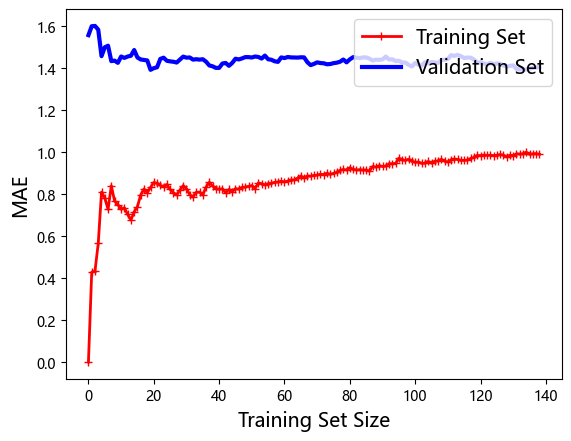

       y_train     y_pred
103  57.133333  55.190504
48   49.200000  52.898715
40   54.500000  52.882377
148  57.533333  54.464548
185  56.200000  54.988128
74   53.100000  52.861973
162  53.000000  53.514136
109  53.333333  52.014807
101  52.000000  54.288528
173  58.466667  54.671317
139  51.900000  53.094223
197  51.333333  52.066293
12   55.100000  54.269899
68   54.600000  54.001687
78   50.532000  53.361499
58   55.200000  54.398191
9    51.200000  52.752968
165  52.200000  53.856580
90   52.434000  54.561739
95   54.885000  54.484632
131  53.066667  53.687207
63   55.100000  53.243500
160  49.800000  53.648676
27   55.200000  53.457508
59   51.100000  53.738971
94   52.442000  52.885121
145  57.200000  54.507873
126  47.800000  54.044248
194  57.600000  54.830001
86   49.245000  52.370007
180  56.400000  53.471366
49   50.800000  53.238990
125  51.566667  52.555375
129  54.600000  54.078832
147  54.933333  54.177980
192  52.233333  54.268318
76   54.691000  52.654776
38   50.1000

In [27]:
_time = time.time()

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
# 划分训练集和测试集|

x=27
#30 17
#16  23 30 60 76
#28 27 70
#36 174
#16 25 28 69 86 116 141
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3
                                                    , random_state=x,shuffle=True)#0.2 2000


    
# 随机森林回归模型
model = RandomForestRegressor(n_estimators=65,
                              max_depth=6,
                              min_samples_split=2,
                              min_samples_leaf=1,
                              max_features=None, 
                              random_state=x)#SSA 200 10 10 6/5   #BO 26 6 5 2

# 五折交叉验证 
#{'max_depth': 3.128081160361883, 'min_samples_leaf': 8.718455049011212, 'min_samples_split': 5.239506316719041, 'n_estimators': 81.123697063534}
cv_scores = cross_val_score(model, X_train, y_train, cv=10, scoring='neg_mean_absolute_error')

# 训练模型
model.fit(X_train, y_train)

# 预测结果
y_pred = model.predict(X_train)
y_pred2 = model.predict(X_test)

# 输出测试集预测值和真实值，并保存到Excel文件中
df = pd.DataFrame({'y_train': y_train, 'y_test': y_test})
with pd.ExcelWriter(r"E:\论文4\产量\测试集预测值和真实值B00000.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)

# 计算评估指标-all特征
mse1 = mean_squared_error(y_train, y_pred)
rmse1 = np.sqrt(mse1)
mae1 = mean_absolute_error(y_train, y_pred)
mape1 = np.mean(np.abs((y_train - y_pred) / y_train)) * 100
r21 = r2_score(y_train, y_pred)
RMSRE1 = np.sqrt(np.mean(((y_train - y_pred) / y_train) ** 2))  
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)
mae2 = mean_absolute_error(y_test, y_pred2)
mape2 = np.mean(np.abs((y_test - y_pred2) / y_test)) * 100
r22 = r2_score(y_test, y_pred2)
RMSRE2 = np.sqrt(np.mean(((y_test - y_pred2) / y_test) ** 2))  

print('TMSE:', mse1)
print('TRMSE:', rmse1)
print('TMAE:', mae1)
print('TMAPE:', mape1)
print('TR²:', r21)
print('TRMSRE:', RMSRE1)

print('VMSE:', mse2)
print('VRMSE:', rmse2)
print('VMAE:', mae2)
print('VMAPE:', mape2)
print('VR²:', r22)
print('VRMSRE:', RMSRE2)
# 在此处插入需要计时的代码
#绘制MAE损失曲线
train_errors, val_errors = [], []
for m in range(1, len(X_train)):
    model.fit(X_train[:m], y_train[:m])
    y_train_pred = model.predict(X_train[:m])
    y_val_pred = model.predict(X_test)
    train_errors.append(mean_absolute_error(y_train[:m], y_train_pred))
    val_errors.append(mean_absolute_error(y_test, y_val_pred))
plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="Training Set")
plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="Validation Set")
plt.legend(loc="upper right", fontsize=14)
plt.xlabel("Training Set Size", fontsize=14)
plt.ylabel("MAE", fontsize=14)
plt.show()

#图形数据输出到指定文件
import pandas as pd

# 创建一个DataFrame对象
output_df = pd.DataFrame({'Training Set Size': range(1, len(X_train)),
                          'Training MAE': np.sqrt(train_errors),
                          'Validation MAE': np.sqrt(val_errors)})
# 将DataFrame写入Excel文件中的第一个工作表
with pd.ExcelWriter(r"E:\论文4\delete-XGBoost损失函数曲线.xlsx") as writer:
    output_df.to_excel(writer, sheet_name='Sheet1', index=False)
##
# 输出测试集预测值和真实值，并保存到Excel文件中
df = pd.DataFrame({'y_test': y_train, 'y_pred': y_pred})
with pd.ExcelWriter(r"E:\论文5\C\训练集和测试集\CatBoost预测与验证值0908.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)

df = pd.DataFrame({'y_train': y_test, 'y_pred': y_pred2})
with pd.ExcelWriter(r"E:\论文5\C\训练集和测试集\CatBoost预测与训练值0908.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet2', index=False)
##
   #writer.save( )
print(df)